In [81]:
import warnings
import FinanceDataReader as fdr
import matplotlib.pyplot as plt 
from matplotlib.figure import Figure
import pandas as pd 
import numpy as np 

warnings.filterwarnings('ignore')

In [82]:
# finance datareader로 부터 데이터 불러오기 
data = fdr.DataReader('KS11') # 코스피 지표
data

,Close,UpDown,Comp,Change,Open,High,Low,Volume,Amount,MarCap
Date,,,,,,,,,,
2010-01-04,1696.14,1,13.37,0.0079,1681.71,1696.14,1681.71,296547959,4364595613797,8.947316e+14
2010-01-05,1690.62,2,-5.52,-0.0033,1701.62,1702.39,1686.45,408854057,6830723338336,8.919010e+14
2010-01-06,1705.32,1,14.70,0.0087,1697.88,1706.89,1696.10,426040121,6391016648164,8.996451e+14
2010-01-07,1683.45,2,-21.87,-0.0128,1702.92,1707.90,1683.45,462402742,7498405146704,8.881114e+14
2010-01-08,1695.26,1,11.81,0.0070,1694.06,1695.26,1668.84,379952313,6965072761490,8.940801e+14
...,...,...,...,...,...,...,...,...,...,...
2026-03-19,5763.22,2,-161.81,-0.0273,5761.40,5863.39,5738.95,1184170077,22994678385098,4.757685e+15
2026-03-20,5781.20,1,17.98,0.0031,5813.35,5833.68,5764.64,1490805229,34025853798776,4.768189e+15
2026-03-23,5405.75,2,-375.45,-0.0649,5580.15,5580.15,5397.94,1125619649,27243225200168,4.459320e+15


In [83]:
# 종가만 추출 
close = data['Close']

# 비교 기준 구간 
strat_date = '2026-03-01'
end_date = '2026-03-25'

<Axes: xlabel='Date'>

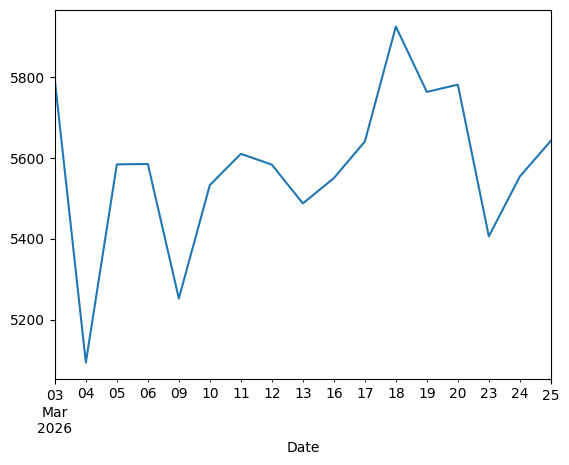

In [84]:
# 기준 구간 시계열 차트 
close[strat_date:end_date].plot()

In [85]:
# 기준점이 되는 종가의 범위 부분을을 base에 담기 
base = close[strat_date:end_date]
base

Date
2026-03-03    5791.91
2026-03-04    5093.54
2026-03-05    5583.90
2026-03-06    5584.87
2026-03-09    5251.87
2026-03-10    5532.59
2026-03-11    5609.95
2026-03-12    5583.25
2026-03-13    5487.24
2026-03-16    5549.85
2026-03-17    5640.48
2026-03-18    5925.03
2026-03-19    5763.22
2026-03-20    5781.20
2026-03-23    5405.75
2026-03-24    5553.92
2026-03-25    5642.21
Name: Close, dtype: float64

In [86]:
# 0과 1 사이에 있는 값을 갖도록 정규화 진행 
base_norm = (base - base.min()) / (base.max() - base.min())
base_norm

Date
2026-03-03    0.839902
2026-03-04    0.000000
2026-03-05    0.589736
2026-03-06    0.590903
2026-03-09    0.190417
2026-03-10    0.528028
2026-03-11    0.621066
2026-03-12    0.588955
2026-03-13    0.473487
2026-03-16    0.548786
2026-03-17    0.657783
2026-03-18    1.000000
2026-03-19    0.805398
2026-03-20    0.827021
2026-03-23    0.375483
2026-03-24    0.553681
2026-03-25    0.659864
Name: Close, dtype: float64

In [87]:
# 윈도우 사이즈 
window_size = len(base)

# 예측 기간 
next_date = 5

# 검색횟수 
moving_cnt = len(close) - window_size - next_date -1

In [88]:
# cosine 유사도
# 1에 가까울수록 유사도가 높음
# 0에 가까울수록 유사도가 떨어짐
def cosine_similarity(x,y):
    return np.dot(x,y) / (np.sqrt(np.dot(x,x))* np.sqrt(np.dot(y,y)))

In [89]:
# 유사도 저장 딕셔너리 
sim_list = []

for i in range(moving_cnt):
    target = close[i:i+window_size]

    # Normalize
    target_norm = (target - target.min()) / (target.max()-target.min())

    # 코사인 유사도 저장 
    cos_similarity = cosine_similarity(base_norm, target_norm)

    # 코사인 유사도 <- i(인덱스), 시계열데이터 함께 저장 
    sim_list.append(cos_similarity)

In [90]:
# 0.94 이상이면 유사한 패턴이라고 내 스스로 정의.
pd.Series(sim_list).sort_values(ascending=False).head(20)

3598    0.957107
489     0.946382
2732    0.942153
2038    0.941858
1107    0.938210
2935    0.937192
602     0.937042
1495    0.936773
1657    0.935001
2903    0.933662
2623    0.933618
23      0.933399
1105    0.930322
1185    0.929640
3045    0.928524
2731    0.928440
2646    0.928070
3441    0.927000
1580    0.926125
2540    0.924376
dtype: float64

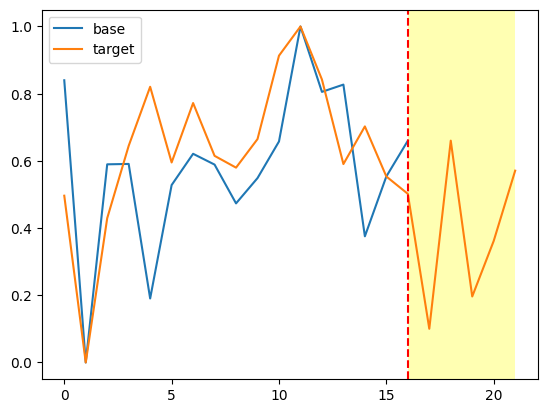

In [91]:
idx =  2732 
top_ = close[idx:idx+window_size+next_date]
top_norm = (top_ - top_.min()) / (top_.max()-top_.min())

plt.plot(base_norm.values, label='base')
plt.plot(top_norm.values, label='target')
plt.axvline(x=len(base_norm)-1, c='r', linestyle='--')
plt.axvspan(len(base_norm.values)-1, len(top_norm.values)-1, facecolor = 'yellow', alpha=0.3)
plt.legend()
plt.show()


In [129]:
class PatternFinder():
    def __init__(self, period=5):
        self.period = period
        
    def set_stock(self, code: str):
        self.code = code
        self.data = fdr.DataReader(code)
        self.close = self.data['Close']
        self.change = self.data['Change']
        return self.data
        
    def search(self, start_date, end_date, threshold=0.94):
        base = self.close[start_date:end_date]
        self.base_norm = (base - base.min()) / (base.max() - base.min())
        self.base = base
        
        display(base)
        
        window_size = len(base)
        moving_cnt = len(self.data) - window_size - self.period - 1
        cos_sims = self.__cosine_sims(moving_cnt, window_size)
        
        self.window_size = window_size
        cos_sims = cos_sims[cos_sims > threshold]
        return cos_sims
    
    def __cosine_sims(self, moving_cnt, window_size):
        def cosine_similarity(x, y):
            return np.dot(x, y) / (np.sqrt(np.dot(x, x)) * np.sqrt(np.dot(y, y)))
            
        sim_list = []

        for i in range(moving_cnt):
            # 💡 수정: close -> self.close (현재 설정된 종목 데이터 사용)
            target = self.close[i:i+window_size]

            # Normalize
            target_norm = (target - target.min()) / (target.max() - target.min())

            # 💡 수정: base_norm -> self.base_norm (현재 설정된 기준 데이터 사용)
            cos_similarity = cosine_similarity(self.base_norm, target_norm)

            sim_list.append(cos_similarity)
            
        return pd.Series(sim_list).sort_values(ascending=False)
    
    def plot_pattern(self, idx, period=5):
        if period != self.period:
            self.period = period
        
        top = self.close[idx:idx+self.window_size+period]
        top_norm = (top - top.min()) / (top.max() - top.min())

        plt.plot(self.base_norm.values, label='base')
        plt.plot(top_norm.values, label='target')
        plt.axvline(x=len(self.base_norm)-1, c='r', linestyle='--')
        plt.axvspan(len(self.base_norm.values)-1, len(top_norm.values)-1, facecolor='yellow', alpha=0.3)
        plt.legend()
        plt.show()

        preds = self.change[idx+self.window_size: idx+self.window_size+period]
        display(preds)
        print(f'pred: {preds.mean()*100} % ')
        
    # 💡 수정: 들여쓰기를 앞으로 당겨서 독립적인 클래스 메서드로 만듦
    def stat_prediction(self, result, period=5):
        idx_list = list(result.keys())
        mean_list = []
        for idx in idx_list:
            pred = self.change[idx+self.window_size: idx+self.window_size+period]
            mean_list.append(pred.mean())
        return np.array(mean_list)

In [130]:
p = PatternFinder()

In [131]:
p.set_stock('005380')

,Open,High,Low,Close,Volume,Change
Date,,,,,,
2014-01-02,236500,238000,224500,224500,720748,NaN
2014-01-03,226500,228000,222500,224000,572466,-0.002227
2014-01-06,224000,231000,222500,228500,669198,0.020089
2014-01-07,232000,232000,228500,229000,464556,0.002188
2014-01-08,230000,231500,228500,229500,242741,0.002183
...,...,...,...,...,...,...
2026-03-19,521000,530000,521000,522000,770000,-0.042202
2026-03-20,527000,528000,517000,517000,1049264,-0.009579
2026-03-23,500000,501000,485000,485000,1603262,-0.061896


In [132]:
# 3월 1일 부터 3월 25일 까지의 삼성전자 주가가 나옴. 
result = p.search('2026-03-01','2026-03-25')

Date
2026-03-03    595000
2026-03-04    501000
2026-03-05    548000
2026-03-06    553000
2026-03-09    507000
2026-03-10    525000
2026-03-11    530000
2026-03-12    521000
2026-03-13    517000
2026-03-16    506000
2026-03-17    522000
2026-03-18    545000
2026-03-19    522000
2026-03-20    517000
2026-03-23    485000
2026-03-24    492000
2026-03-25    501000
Name: Close, dtype: int64

In [133]:
result

100    0.9414
dtype: float64

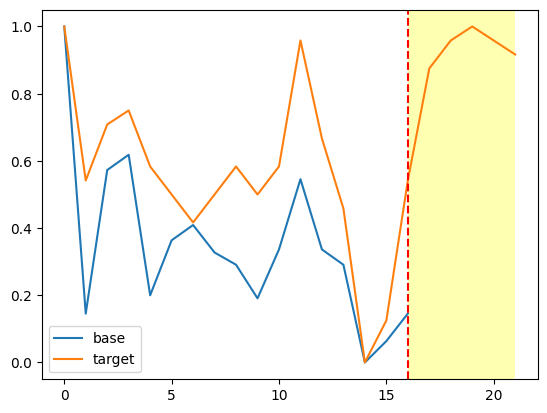

Date
2014-06-25    0.017817
2014-06-26    0.004376
2014-06-27    0.002179
2014-06-30   -0.002174
2014-07-01   -0.002179
Name: Change, dtype: float64

pred: 0.40039653018080656 % 


In [134]:
p.plot_pattern(100)